In [1]:
from workloads import vgg16, simple_net
from workloads.common import *

from roofline.roofline_model import *

# net = vgg16.network(resolutions['original'])
# save_path = 'files/vgg16'

net = simple_net.network(resolutions['original'])
save_path = 'files/simple_net'

board_part = 'zcu102'
double_buff=False
num_hp = 1
t_factor = 2
bits = 9
buswidth = 128



  3%|▎         | 16253/524288 [00:00<00:03, 162527.06it/s]

cuttent layer:  conv1_1


  2%|▏         | 43562/2097152 [00:00<00:09, 216760.23it/s]

cuttent layer:  conv1_2


  3%|▎         | 33009/1048576 [00:00<00:03, 330076.15it/s]

...

 26%|██▌       | 67680/262144 [00:00<00:00, 337413.02it/s]

cuttent layer:  conv2_2


100%|██████████| 65536/65536 [00:00<00:00, 335502.55it/s]

cuttent layer:  conv3_1


averaged Tr = 35.2, Tc = 60.8, Tn = 20, Tm = 44.8
sum of each layer exec_cycles:  1313696.0
sum of uniformed layer exec_cycles:  2907198.7199999997
latency(ms):  14.535993599999998


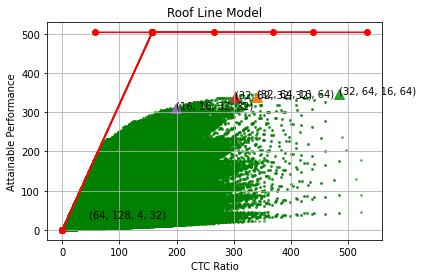

In [2]:
sol_ls = []
layer_cycles = []
for layer_idx in net.keys():
    print("cuttent layer: ", layer_idx)
    layer_meta = net[layer_idx]

    # search design for a layer
    pair_ls, comp_bnd, bw_bnd, solution = DSE_layer(\
        layer_meta, board_part, layer_idx, bits, buswidth, t_factor, save_path, \
        double_buff=double_buff, num_hp = num_hp)

    sol_ls.append(solution[1])
    R = layer_meta['niy']; C = layer_meta['nix']; N = layer_meta['nif']; M = layer_meta['nof']; K = layer_meta['kernel']
    S = 1
    Tr = solution[1][0];Tc = solution[1][1];Tn = solution[1][2];Tm = solution[1][3]
    layer_cycles.append(exec_cycles(R, C, N, M, Tr, Tc, Tn, Tm, S, K))

# averaged to final solution
avg_Tr = list(zip(*sol_ls))[0]; avg_Tr = statistics.mean(avg_Tr)
avg_Tc = list(zip(*sol_ls))[1]; avg_Tc = statistics.mean(avg_Tc)
avg_Tn = list(zip(*sol_ls))[2]; avg_Tn = statistics.mean(avg_Tn)
avg_Tm = list(zip(*sol_ls))[3]; avg_Tm = statistics.mean(avg_Tm)

all_layer_cycle = 0
for layer_idx in net.keys():
    layer_meta = net[layer_idx]
    # count each layer time
    R = layer_meta['niy']; C = layer_meta['nix']; N = layer_meta['nif']; M = layer_meta['nof']; K = layer_meta['kernel']
    S = 1
    all_layer_cycle += exec_cycles(R, C, N, M, avg_Tr, avg_Tc, avg_Tn, avg_Tm, S, K)

print("averaged Tr = {}, Tc = {}, Tn = {}, Tm = {}".format(avg_Tr, avg_Tc, avg_Tn, avg_Tm))
print("sum of each layer exec_cycles: ", sum(layer_cycles))
print("sum of uniformed layer exec_cycles: ", all_layer_cycle)
print("latency(ms): ", all_layer_cycle/(200*(10**6)) * (10**3))

In [17]:
Tr = 32; Tc =32; Tn = 16; Tm = 16; K=3; S=1

In [18]:
all_layer_cycle = 0
for layer_idx in net.keys():
    layer_meta = net[layer_idx]
    # count each layer time
    R = layer_meta['niy']; C = layer_meta['nix']; N = layer_meta['nif']; M = layer_meta['nof']; K = layer_meta['kernel']
    S = 1
    each_layer_cycle = exec_cycles(R, C, N, M, Tr, Tc, Tn, Tm, S, K)
    print(each_layer_cycle)
    all_layer_cycle += each_layer_cycle

print("averaged Tr = {}, Tc = {}, Tn = {}, Tm = {}".format(Tr, Tc, Tn, Tm))
print("sum of each layer exec_cycles: ", sum(layer_cycles))
print("sum of uniformed layer exec_cycles: ", all_layer_cycle)
print("latency(ms): ", all_layer_cycle/(200*(10**6)) * (10**3))

1477120.0
1411584.0
689408.0
172352.0
45376.0
averaged Tr = 32, Tc = 32, Tn = 16, Tm = 16
sum of each layer exec_cycles:  1313696.0
sum of uniformed layer exec_cycles:  3795840.0
latency(ms):  18.979200000000002


In [ ]:
736384.0
703616.0
343616.0
87328.0
23840.0

In [ ]:
739840.0
707072.0
345344.0
88192.0
24704.0

In [34]:
beta_in = Tn * (S*Tr + K-S) * (S*Tc + K-S)
beta_wgt = Tn * Tm * K * K
beta_out = Tm * Tr * Tc

In [35]:
bram_usage(beta_in, beta_wgt, beta_out, Tn, Tm, bits = 9, double_buff=False)

329

In [37]:
dsp_usage(Tn, Tm, bits=9)

512